# 05 — Win Rate Analysis & Market Price Estimation

**Task 2.3.5 (SP2)**: iPinYou RTB market price CDF 추정 → SP3 bid shading 입력.

## Key Findings

1. **Flat Bidding Reality**: iPinYou uses only 6 discrete bid prices (227–300 CPM) across all advertisers — traditional win rate elasticity is limited; cross-advertiser pooling required.
2. **KM Market Price CDF**: True market price median is **above 300 CPM** (unidentifiable due to right-censoring at max bid=300). At bid=300, F(300) ≈ 21% — confirming heavy underbidding. Winners-only biased median is 68 CPM.
3. **Exchange-Conditional CDF**: Ex1 has highest win rate at same bid (median ~153 CPM), Ex2/Ex3 more competitive (median > 300) — exchange-conditional shading essential for SP3.
4. **Parametric Fit**: LogNormal provides best AIC/BIC fit to non-floor observations, suitable for closed-form shade(x) optimization.
5. **S2→S3 Temporal Drift**: S2→S3 KS ≈ 0.13 (winners-only pay prices), S3 market prices shifted rightward — periodic CDF re-estimation needed in production.
6. **SP3 Shade Demo**: For V(x)=200 CPM, optimal bid = 89 CPM (shade = 44.6%), expected surplus = 17.2 CPM.

## Section 1: Setup

In [44]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_PATH = PROJECT_ROOT / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
DATA_PATH = PROJECT_ROOT / 'data' / 'ipinyou' / 'prediction' / 'features'
FIG_PATH.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

from src.win_rate.nonparametric import (
    wilson_ci,
    empirical_win_rate_curve,
    compute_market_price_stats,
    empirical_market_cdf,
)
from src.win_rate.survival import (
    estimate_market_cdf_km,
    estimate_market_cdf_parametric,
    compare_parametric_fits,
    segment_market_cdf,
    validate_cdf_vs_empirical,
)

print('Setup complete.')

Setup complete.


In [45]:
# Load data — use only columns needed for this analysis
COLS = ['bidprice', 'payprice', 'slotprice', 'win', 'click',
        'adexchange', 'advertiser', 'hour', 'season']

df_train = pd.read_parquet(DATA_PATH / 'train.parquet', columns=COLS)
df_test = pd.read_parquet(DATA_PATH / 'test.parquet', columns=COLS)

# Ensure numpy-friendly dtypes (Arrow backend → numpy)
for col in ['bidprice', 'payprice', 'slotprice', 'win', 'click', 'adexchange', 'hour']:
    for df in [df_train, df_test]:
        if hasattr(df[col], 'to_numpy'):
            df[col] = df[col].to_numpy(dtype='float64' if col in ['bidprice','payprice','slotprice'] else None, na_value=0)

print(f'Train: {len(df_train):,} rows, Win rate: {df_train["win"].mean():.4f}')
print(f'Test:  {len(df_test):,} rows, Win rate: {df_test["win"].mean():.4f}')

Train: 90,645,448 rows, Win rate: 0.2099
Test:  19,424,025 rows, Win rate: 0.2180


## Section 2: Flat Bidding Reality Check

iPinYou DSP uses **flat bidding**: each (advertiser, exchange) combination bids at a single fixed price.
This means the entire dataset has only ~6 unique bid values — traditional smooth win rate curves
cannot be estimated from a single advertiser. Cross-advertiser pooling introduces confounding
(different advertisers target different segments), which limits causal interpretation.

In [46]:
# Unique bid prices per advertiser × exchange
bid_summary = (
    df_train
    .groupby(['advertiser', 'adexchange'])
    .agg(
        bid_price=('bidprice', 'first'),
        n_bids=('bidprice', 'count'),
        n_unique_bids=('bidprice', 'nunique'),
        win_rate=('win', 'mean'),
    )
    .reset_index()
    .sort_values('n_bids', ascending=False)
)

print(f'Unique bid values in dataset: {df_train["bidprice"].nunique()}')
print(f'\nBid summary (advertiser × exchange):')
display(bid_summary.head(20))

Unique bid values in dataset: 6

Bid summary (advertiser × exchange):


,advertiser,adexchange,bid_price,n_bids,n_unique_bids,win_rate
8,3386,3,300.0,19277303,1,0.100505
2,1458,3,300.0,18735996,1,0.093143
10,3427,2,238.0,13436724,1,0.098571
11,3427,3,241.0,9915498,1,0.153577
14,3476,3,254.0,8594553,1,0.150812
1,1458,2,300.0,3990252,1,0.347761
3,3358,1,227.0,2512110,1,0.536006
7,3386,2,300.0,2277222,1,0.616308
13,3476,2,249.0,1940304,1,0.603361
4,3358,2,238.0,1888848,1,0.509030


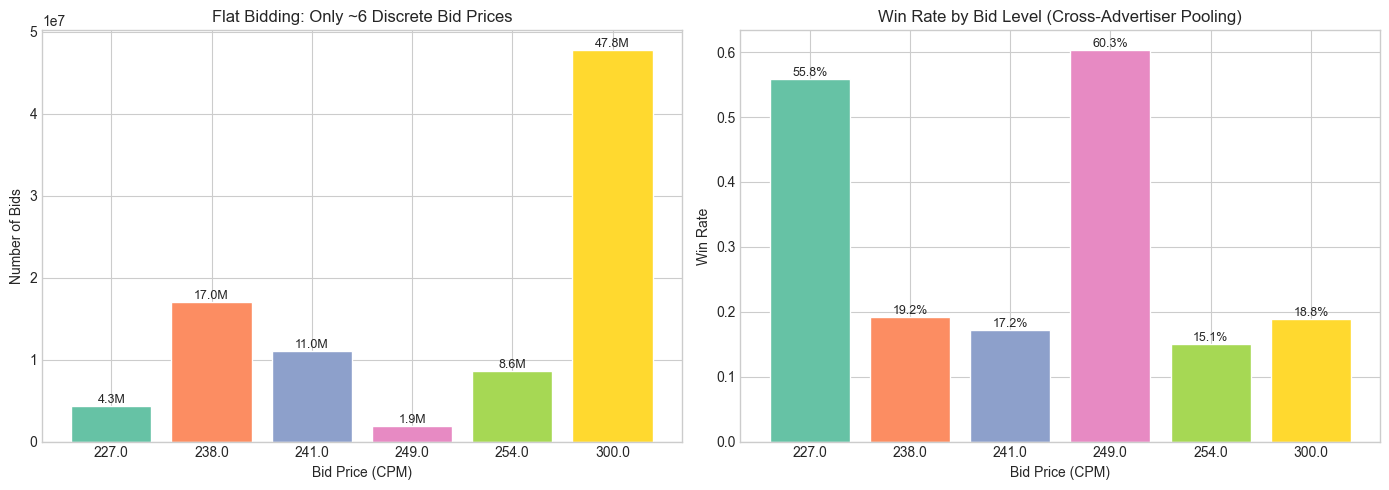

Saved: 05_flat_bidding_summary.png


In [47]:
# Visualize flat bidding structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bid price distribution
bid_counts = df_train['bidprice'].value_counts().sort_index()
axes[0].bar(bid_counts.index.astype(str), bid_counts.values, color=sns.color_palette('Set2'))
axes[0].set_xlabel('Bid Price (CPM)')
axes[0].set_ylabel('Number of Bids')
axes[0].set_title('Flat Bidding: Only ~6 Discrete Bid Prices')
for i, (bp, cnt) in enumerate(zip(bid_counts.index, bid_counts.values)):
    axes[0].text(i, cnt, f'{cnt/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# Right: win rate by bid price
wr_by_bid = (
    df_train
    .groupby('bidprice')
    .agg(win_rate=('win', 'mean'), n=('win', 'count'))
    .reset_index()
)
axes[1].bar(wr_by_bid['bidprice'].astype(str), wr_by_bid['win_rate'], color=sns.color_palette('Set2'))
axes[1].set_xlabel('Bid Price (CPM)')
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate by Bid Level (Cross-Advertiser Pooling)')
for i, row in wr_by_bid.iterrows():
    axes[1].text(i, row['win_rate'], f'{row["win_rate"]:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / '05_flat_bidding_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_flat_bidding_summary.png')

## Section 3: Aggregate Win Rate by Bid Level

Despite flat bidding, cross-advertiser pooling reveals the expected monotonic relationship:
higher bids → higher win rates. We stratify by exchange to isolate market structure effects.

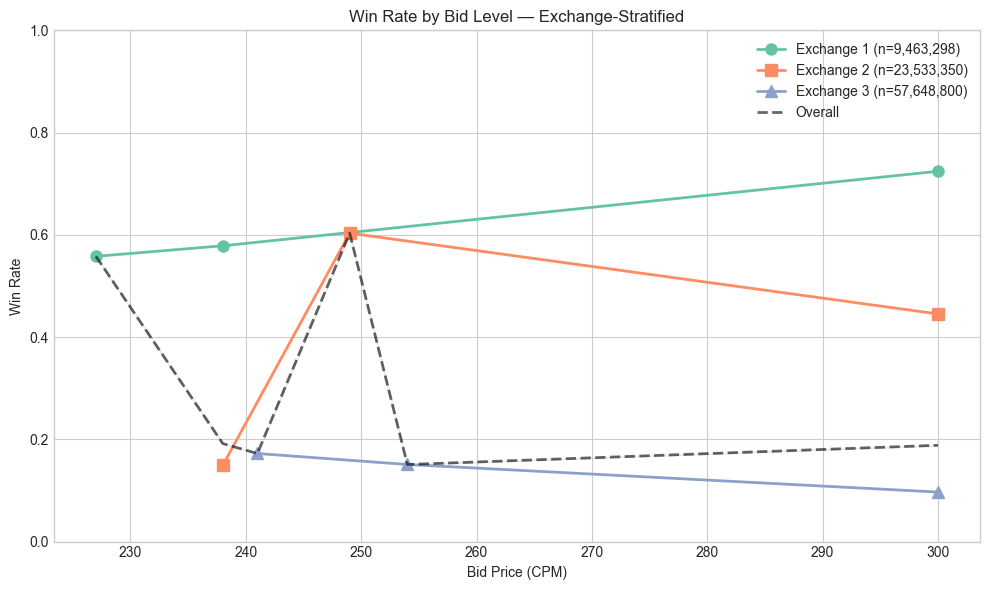

Saved: 05_win_rate_by_bid_level.png


In [48]:
# Win rate by bid level × exchange
wr_bid_ex = (
    df_train
    .groupby(['bidprice', 'adexchange'])
    .agg(win_rate=('win', 'mean'), n=('win', 'count'))
    .reset_index()
    .assign(adexchange=lambda d: d['adexchange'].astype(int))
)

fig, ax = plt.subplots(figsize=(10, 6))

exchange_labels = {1: 'Exchange 1', 2: 'Exchange 2', 3: 'Exchange 3'}
markers = {1: 'o', 2: 's', 3: '^'}

for ex in sorted(wr_bid_ex['adexchange'].unique()):
    sub = wr_bid_ex[wr_bid_ex['adexchange'] == ex].sort_values('bidprice')
    if len(sub) < 2:
        continue
    label = exchange_labels.get(ex, f'Exchange {ex}')
    ax.plot(sub['bidprice'], sub['win_rate'], marker=markers.get(ex, 'o'),
            label=f'{label} (n={sub["n"].sum():,.0f})', linewidth=2, markersize=8)

# Overall curve
curve = empirical_win_rate_curve(df_train['bidprice'].values, df_train['win'].values)
ax.plot(curve.bid_midpoints, curve.win_rates, 'k--', linewidth=2, alpha=0.6, label='Overall')
ax.fill_between(curve.bid_midpoints, curve.ci_lower, curve.ci_upper, alpha=0.15, color='gray')

ax.set_xlabel('Bid Price (CPM)')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Bid Level — Exchange-Stratified')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_PATH / '05_win_rate_by_bid_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_win_rate_by_bid_level.png')

## Section 4: Market Price Distribution (Winners Only)

Observed pay prices are available only for won auctions (23.67% of bids).
This is a **biased** view — the true market price distribution includes
unobserved prices above our bids (Section 5 corrects this with KM).

In [49]:
# Winners only
winners = df_train[df_train['win'] == 1].copy()
print(f'Winners: {len(winners):,} ({len(winners)/len(df_train):.2%} of bids)')

# Market price stats
stats = compute_market_price_stats(winners['payprice'].values, winners['slotprice'].values)
print(f'\nMarket Price Statistics (Winners Only):')
print(f'  Mean:   {stats.mean:.1f} CPM')
print(f'  Median: {stats.median:.1f} CPM')
print(f'  Std:    {stats.std:.1f} CPM')
print(f'  P25:    {stats.p25:.1f}, P75: {stats.p75:.1f}, P90: {stats.p90:.1f}, P95: {stats.p95:.1f}')
print(f'  Floor binding rate: {stats.floor_binding_rate:.1%}')

Winners: 19,025,318 (20.99% of bids)

Market Price Statistics (Winners Only):
  Mean:   78.1 CPM
  Median: 68.0 CPM
  Std:    59.4 CPM
  P25:    36.0, P75: 93.0, P90: 166.0, P95: 214.0
  Floor binding rate: 20.8%


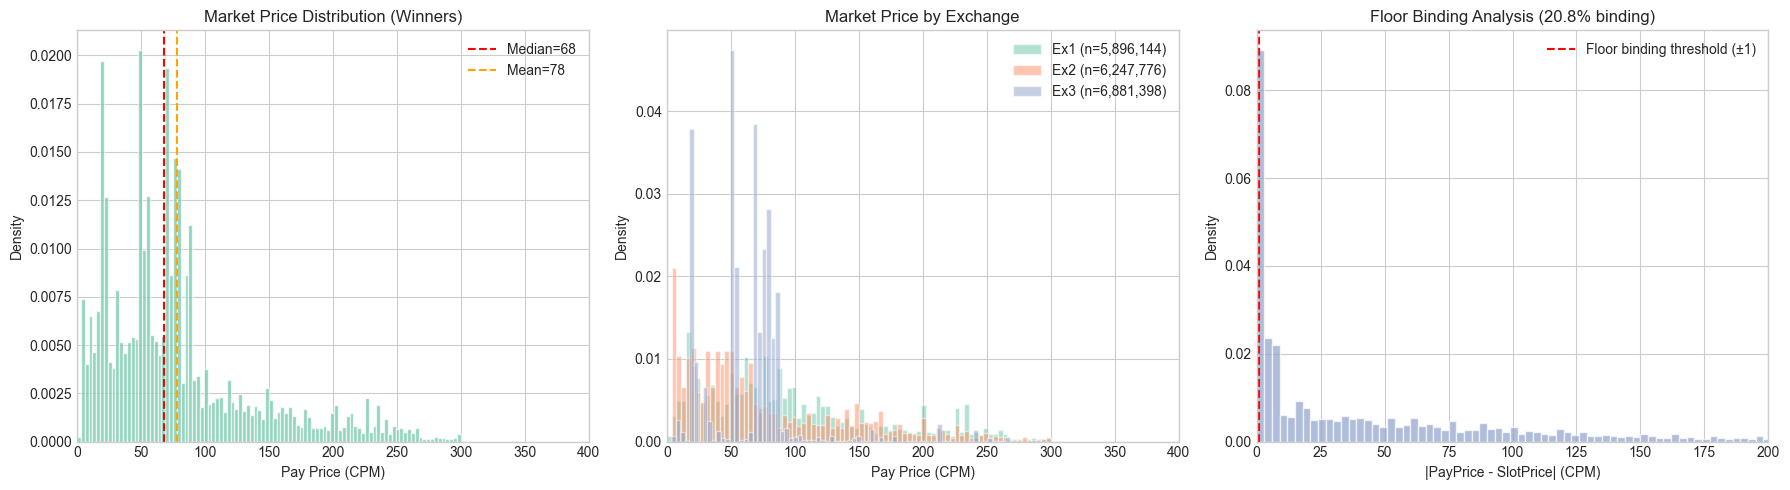

Saved: 05_market_price_distribution.png


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall payprice histogram
axes[0].hist(winners['payprice'].values, bins=100, density=True, alpha=0.7,
             color=sns.color_palette('Set2')[0], edgecolor='white')
axes[0].axvline(stats.median, color='red', linestyle='--', label=f'Median={stats.median:.0f}')
axes[0].axvline(stats.mean, color='orange', linestyle='--', label=f'Mean={stats.mean:.0f}')
axes[0].set_xlabel('Pay Price (CPM)')
axes[0].set_ylabel('Density')
axes[0].set_title('Market Price Distribution (Winners)')
axes[0].set_xlim(0, 400)
axes[0].legend()

# 2. Exchange-conditional
for ex in sorted(winners['adexchange'].unique()):
    sub = winners[winners['adexchange'] == ex]
    if len(sub) < 100:
        continue
    axes[1].hist(sub['payprice'].values, bins=80, density=True, alpha=0.5,
                 label=f'Ex{int(ex)} (n={len(sub):,})')
axes[1].set_xlabel('Pay Price (CPM)')
axes[1].set_ylabel('Density')
axes[1].set_title('Market Price by Exchange')
axes[1].set_xlim(0, 400)
axes[1].legend()

# 3. Floor binding analysis
floor_diff = np.abs(winners['payprice'].values - winners['slotprice'].values)
axes[2].hist(floor_diff, bins=100, density=True, alpha=0.7,
             color=sns.color_palette('Set2')[2], edgecolor='white')
axes[2].axvline(1.0, color='red', linestyle='--', label='Floor binding threshold (±1)')
axes[2].set_xlabel('|PayPrice - SlotPrice| (CPM)')
axes[2].set_ylabel('Density')
axes[2].set_title(f'Floor Binding Analysis ({stats.floor_binding_rate:.1%} binding)')
axes[2].set_xlim(0, 200)
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_PATH / '05_market_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_market_price_distribution.png')

## Section 5: KM Market Price CDF

### Censoring Framework

The true market price (minimum price needed to win) is:
- **Observed** if we won: `market_price = payprice` → event at payprice
- **Censored** if we lost: `market_price > bidprice` → right-censored at bidprice

Kaplan-Meier estimates `S(p) = P(market_price > p)`, so:
- `F(p) = 1 - S(p) = P(Win | bid = p)` — the **win probability at bid p**
- This is the direct input for SP3 bid shading: `shade(x) = argmax_b (v - b) × F(b)`

**Limitation**: Right-censoring stops at max(bidprice)=300, so the right tail of the market
price distribution beyond 300 CPM is unidentifiable.

In [51]:
# Subsample for initial KM fitting (full data can be slow)
N_SUBSAMPLE = 5_000_000
rng = np.random.RandomState(42)

if len(df_train) > N_SUBSAMPLE:
    idx = rng.choice(len(df_train), N_SUBSAMPLE, replace=False)
    df_km = df_train.iloc[idx].copy()
    print(f'Subsampled to {N_SUBSAMPLE:,} rows for KM fitting')
else:
    df_km = df_train.copy()
    print(f'Using full training data: {len(df_km):,} rows')

# Shared price grid
PRICE_GRID = np.linspace(0, 500, 1000)

Subsampled to 5,000,000 rows for KM fitting


In [52]:
%%time
# KM fit
km_result = estimate_market_cdf_km(
    bidprice=df_km['bidprice'].values,
    payprice=df_km['payprice'].values,
    win=df_km['win'].values,
    price_grid=PRICE_GRID,
)

# Display median — may be inf if S(p) never drops to 0.5 (heavy right-censoring)
if np.isinf(km_result.median_price):
    max_bid = df_km['bidprice'].max()
    s_at_max = np.interp(max_bid, km_result.price_grid, km_result.survival)
    print(f'KM Median Market Price: > {max_bid:.0f} CPM (unidentifiable — S({max_bid:.0f})={s_at_max:.2%} > 50%)')
    print(f'  → True market price median exceeds max bid. Most auctions are lost.')
else:
    print(f'KM Median Market Price: {km_result.median_price:.1f} CPM')

print(f'\nKM CDF at key points:')
for p in [50, 100, 150, 200, 250, 300]:
    f_p = np.interp(p, km_result.price_grid, km_result.cdf)
    print(f'  F({p}) = {f_p:.4f} ({f_p:.2%} win prob at bid={p})')

# Empirical CDF (biased baseline)
emp_grid, emp_cdf = empirical_market_cdf(winners['payprice'].values, n_points=500)

KM Median Market Price: > 300 CPM (unidentifiable — S(300)=78.68% > 50%)
  → True market price median exceeds max bid. Most auctions are lost.

KM CDF at key points:
  F(50) = 0.0766 (7.66% win prob at bid=50)
  F(100) = 0.1615 (16.15% win prob at bid=100)
  F(150) = 0.1832 (18.32% win prob at bid=150)
  F(200) = 0.1957 (19.57% win prob at bid=200)
  F(250) = 0.2072 (20.72% win prob at bid=250)
  F(300) = 0.2132 (21.32% win prob at bid=300)
CPU times: user 299 ms, sys: 83.5 ms, total: 383 ms
Wall time: 409 ms


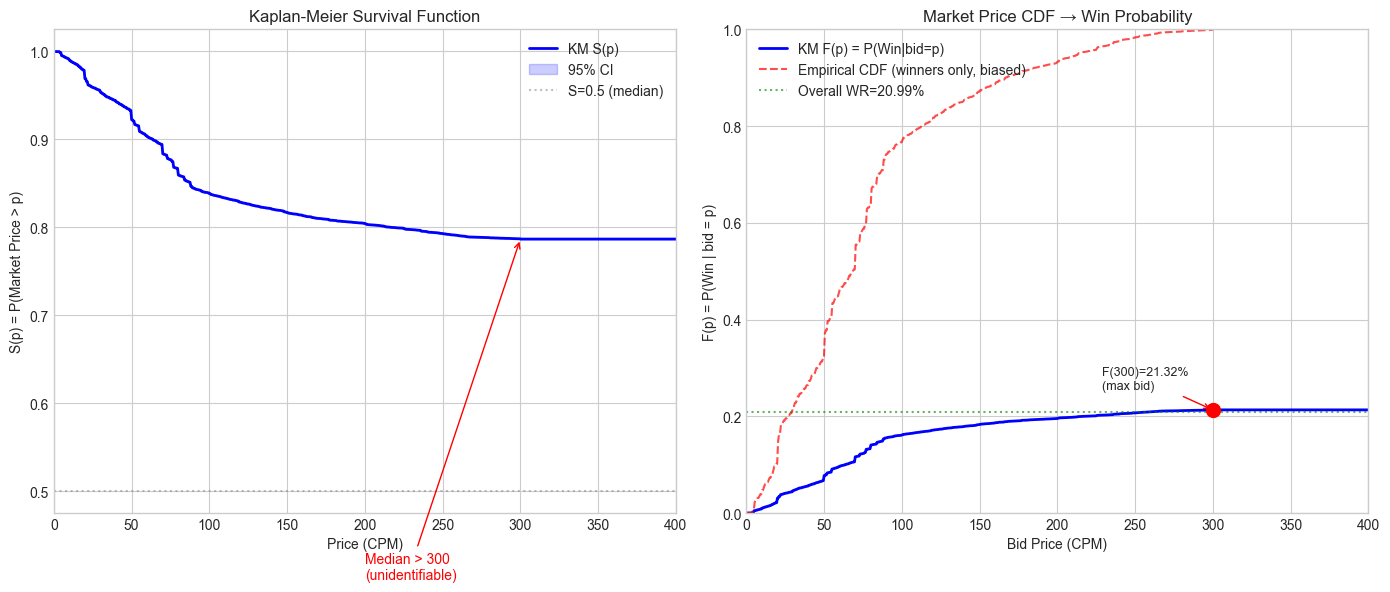

Saved: 05_km_market_cdf.png

Sanity check: F(max_bid=300) = 0.2132
Overall win rate = 0.2099
Note: F(max_bid) ≈ overall_WR confirms KM is well-calibrated.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Survival function S(p)
axes[0].plot(km_result.price_grid, km_result.survival, 'b-', linewidth=2, label='KM S(p)')
if not np.all(np.isnan(km_result.ci_lower)):
    axes[0].fill_between(km_result.price_grid, km_result.ci_lower, km_result.ci_upper,
                         alpha=0.2, color='blue', label='95% CI')
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='S=0.5 (median)')
if not np.isinf(km_result.median_price):
    axes[0].axvline(km_result.median_price, color='red', linestyle='--',
                    label=f'Median={km_result.median_price:.1f}')
else:
    axes[0].annotate('Median > 300\n(unidentifiable)',
                     xy=(300, np.interp(300, km_result.price_grid, km_result.survival)),
                     xytext=(200, 0.4), fontsize=10, color='red',
                     arrowprops=dict(arrowstyle='->', color='red'))
axes[0].set_xlabel('Price (CPM)')
axes[0].set_ylabel('S(p) = P(Market Price > p)')
axes[0].set_title('Kaplan-Meier Survival Function')
axes[0].set_xlim(0, 400)
axes[0].legend()

# Right: CDF F(p) = P(Win | bid=p)
axes[1].plot(km_result.price_grid, km_result.cdf, 'b-', linewidth=2, label='KM F(p) = P(Win|bid=p)')
axes[1].plot(emp_grid, emp_cdf, 'r--', linewidth=1.5, alpha=0.7, label='Empirical CDF (winners only, biased)')
axes[1].axhline(df_train['win'].mean(), color='green', linestyle=':', alpha=0.6,
                label=f'Overall WR={df_train["win"].mean():.2%}')

# Mark max bid price and corresponding F(max_bid)
max_bid = df_train['bidprice'].max()
km_at_max_bid = np.interp(max_bid, km_result.price_grid, km_result.cdf)
axes[1].plot(max_bid, km_at_max_bid, 'ro', markersize=10, zorder=5)
axes[1].annotate(f'F({max_bid:.0f})={km_at_max_bid:.2%}\n(max bid)',
                 (max_bid, km_at_max_bid), textcoords='offset points',
                 xytext=(-80, 15), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='red'))

axes[1].set_xlabel('Bid Price (CPM)')
axes[1].set_ylabel('F(p) = P(Win | bid = p)')
axes[1].set_title('Market Price CDF → Win Probability')
axes[1].set_xlim(0, 400)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIG_PATH / '05_km_market_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_km_market_cdf.png')

# Sanity check
print(f'\nSanity check: F(max_bid={max_bid:.0f}) = {km_at_max_bid:.4f}')
print(f'Overall win rate = {df_train["win"].mean():.4f}')
print(f'Note: F(max_bid) ≈ overall_WR confirms KM is well-calibrated.')

## Section 6: Exchange-Conditional CDF

Different exchanges have different market structures:
- **Exchange 1**: No floor price → wider price distribution
- **Exchange 2**: Moderate floor → intermediate
- **Exchange 3**: Active floor binding → mass point at floor price

In [54]:
%%time
# Segment KM by exchange
exchange_cdfs = segment_market_cdf(
    df_km, segment_col='adexchange', price_grid=PRICE_GRID, min_samples=1000
)
print(f'Fitted {len(exchange_cdfs)} exchange-conditional CDFs')
for ex, res in sorted(exchange_cdfs.items()):
    med_str = f'{res.median_price:.1f}' if not np.isinf(res.median_price) else '>300'
    f300 = np.interp(300, res.price_grid, res.cdf)
    print(f'  Exchange {ex}: median={med_str} CPM, F(300)={f300:.2%}')

Fitted 3 exchange-conditional CDFs
  Exchange 1: median=153.0 CPM, F(300)=68.80%
  Exchange 2: median=>300 CPM, F(300)=29.06%
  Exchange 3: median=>300 CPM, F(300)=11.95%
CPU times: user 208 ms, sys: 111 ms, total: 319 ms
Wall time: 338 ms


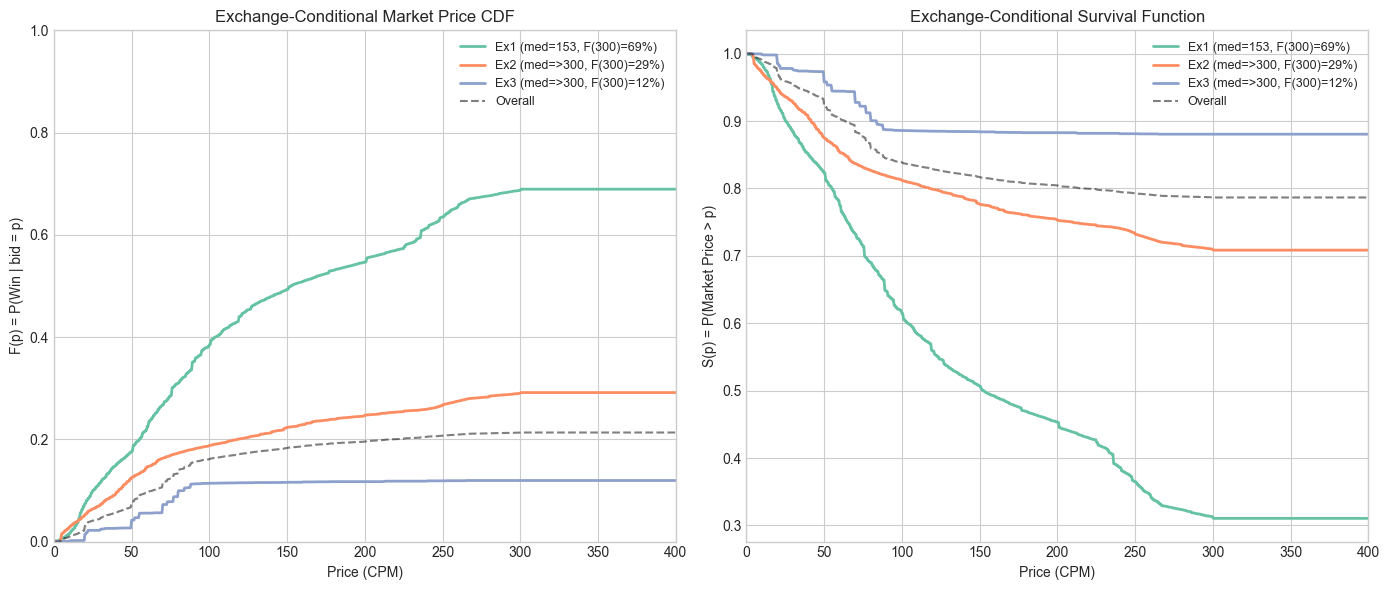

Saved: 05_exchange_conditional_cdf.png

Floor binding rate by exchange:
  Exchange 1: 0.0% (n=5,896,144)
  Exchange 2: 12.5% (n=6,247,776)
  Exchange 3: 46.1% (n=6,881,398)


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = sns.color_palette('Set2', len(exchange_cdfs))

for i, (ex, res) in enumerate(sorted(exchange_cdfs.items())):
    med_str = f'{res.median_price:.0f}' if not np.isinf(res.median_price) else '>300'
    f300 = np.interp(300, res.price_grid, res.cdf)
    label = f'Ex{ex} (med={med_str}, F(300)={f300:.0%})'
    # CDF
    axes[0].plot(res.price_grid, res.cdf, linewidth=2, color=colors[i], label=label)
    # Survival
    axes[1].plot(res.price_grid, res.survival, linewidth=2, color=colors[i], label=label)

# Overall KM for reference
axes[0].plot(km_result.price_grid, km_result.cdf, 'k--', linewidth=1.5, alpha=0.5, label='Overall')
axes[1].plot(km_result.price_grid, km_result.survival, 'k--', linewidth=1.5, alpha=0.5, label='Overall')

axes[0].set_xlabel('Price (CPM)')
axes[0].set_ylabel('F(p) = P(Win | bid = p)')
axes[0].set_title('Exchange-Conditional Market Price CDF')
axes[0].set_xlim(0, 400)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Price (CPM)')
axes[1].set_ylabel('S(p) = P(Market Price > p)')
axes[1].set_title('Exchange-Conditional Survival Function')
axes[1].set_xlim(0, 400)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / '05_exchange_conditional_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_exchange_conditional_cdf.png')

# Floor binding by exchange
print('\nFloor binding rate by exchange:')
for ex in sorted(df_train['adexchange'].unique()):
    sub_w = winners[winners['adexchange'] == ex]
    if len(sub_w) < 100:
        continue
    fb = np.mean(np.abs(sub_w['payprice'].values - sub_w['slotprice'].values) < 1.0)
    print(f'  Exchange {int(ex)}: {fb:.1%} (n={len(sub_w):,})')

## Section 7: Hourly Market CDF

Market competition intensity varies by hour of day. We examine how the
median market price and win rate shift across hours — confirming the
U-shape pattern from EDA (low competition at night, high during afternoon).

In [56]:
%%time
# Hourly KM CDFs (subsample per hour to keep fast)
hourly_medians = []
hourly_wr = []

for h in range(24):
    sub = df_km[df_km['hour'] == h]
    if len(sub) < 1000:
        continue
    km_h = estimate_market_cdf_km(
        bidprice=sub['bidprice'].values,
        payprice=sub['payprice'].values,
        win=sub['win'].values,
        price_grid=PRICE_GRID,
    )
    hourly_medians.append({'hour': h, 'km_median': km_h.median_price})
    hourly_wr.append({'hour': h, 'win_rate': sub['win'].mean(), 'n': len(sub)})

hourly_df = pd.DataFrame(hourly_medians).merge(pd.DataFrame(hourly_wr), on='hour')
print('Hourly KM fitting complete.')

Hourly KM fitting complete.
CPU times: user 379 ms, sys: 101 ms, total: 480 ms
Wall time: 489 ms


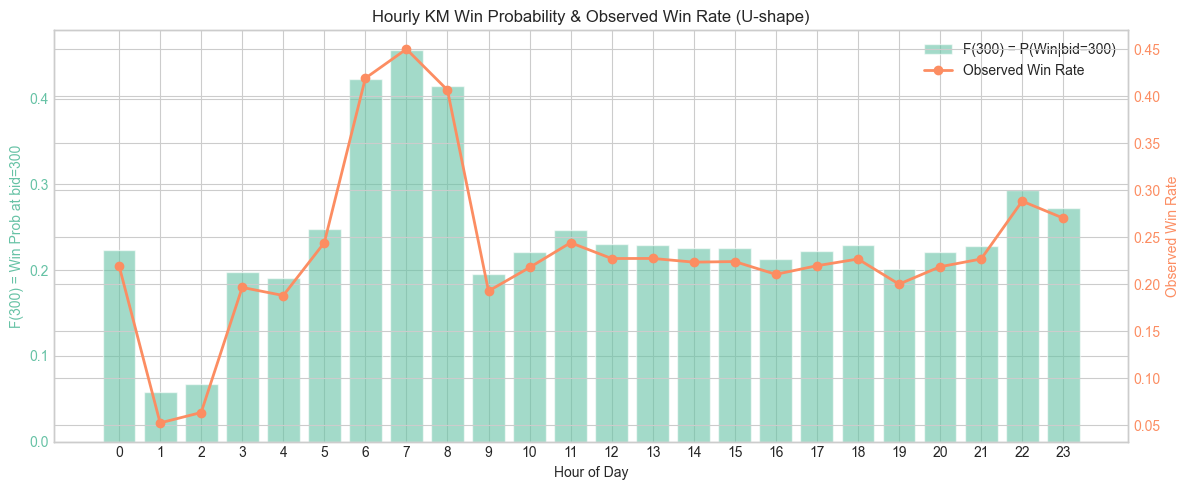

Saved: 05_hourly_market_cdf.png


In [57]:
# Replace inf medians with NaN for plotting, use F(300) as alternative metric
hourly_df['km_median_plot'] = hourly_df['km_median'].replace(np.inf, np.nan)

# Compute F(300) per hour as an alternative when median is inf
hourly_f300 = []
for h in range(24):
    sub = df_km[df_km['hour'] == h]
    if len(sub) < 1000:
        continue
    km_h = estimate_market_cdf_km(
        bidprice=sub['bidprice'].values,
        payprice=sub['payprice'].values,
        win=sub['win'].values,
        price_grid=PRICE_GRID,
    )
    f300 = np.interp(300, km_h.price_grid, km_h.cdf)
    hourly_f300.append({'hour': h, 'f300': f300})
hourly_df = hourly_df.merge(pd.DataFrame(hourly_f300), on='hour', how='left')

fig, ax1 = plt.subplots(figsize=(12, 5))

color1, color2 = sns.color_palette('Set2')[:2]

# Use F(300) as the primary metric (since most medians are inf)
ax1.bar(hourly_df['hour'], hourly_df['f300'], alpha=0.6, color=color1,
        label='F(300) = P(Win|bid=300)')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('F(300) = Win Prob at bid=300', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(hourly_df['hour'], hourly_df['win_rate'], 'o-', color=color2, linewidth=2,
         markersize=6, label='Observed Win Rate')
ax2.set_ylabel('Observed Win Rate', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Hourly KM Win Probability & Observed Win Rate (U-shape)')
ax1.set_xticks(range(24))

plt.tight_layout()
plt.savefig(FIG_PATH / '05_hourly_market_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_hourly_market_cdf.png')

## Section 8: Parametric Distribution Fitting

We fit Weibull, LogNormal, and Exponential distributions to the censored data
and compare via AIC/BIC. The best parametric fit provides a closed-form CDF
for SP3 shade(x) optimization.

**Note**: Parametric fits are performed on non-floor-bound observations
(where pay > floor + 1) to avoid the discrete mass point at floor price.
A mixture model (floor-point-mass + continuous) would be ideal but is out of scope.

In [58]:
%%time
# Fit on a subsample for speed, excluding floor-bound observations from parametric fit
N_PARA = min(2_000_000, len(df_km))
df_para = df_km.sample(N_PARA, random_state=42).copy()

# For parametric: exclude floor-bound winners (mass point)
floor_mask = (
    (df_para['win'] == 1) &
    (np.abs(df_para['payprice'].values - df_para['slotprice'].values) < 1.0)
)
df_para_nf = df_para[~floor_mask].copy()
print(f'Parametric fitting: {len(df_para_nf):,} rows (excluded {floor_mask.sum():,} floor-bound winners)')

# Compare fits
comparison = compare_parametric_fits(
    df_para_nf['bidprice'].values,
    df_para_nf['payprice'].values,
    df_para_nf['win'].values,
)
print('\nParametric Fit Comparison (AIC/BIC):')
display(comparison)

Parametric fitting: 1,912,692 rows (excluded 87,308 floor-bound winners)

Parametric Fit Comparison (AIC/BIC):


,distribution,aic,bic,params
0,lognormal,5.386700e+06,5.386725e+06,"{'mu_': 7.931047990590656, 'sigma_': 2.5214134..."
1,weibull,5.429250e+06,5.429275e+06,"{'lambda_': 2724.0742752900287, 'rho_': 0.7132..."
2,exponential,5.475015e+06,5.475028e+06,{'lambda_': 1383.0724623205788}


CPU times: user 16.1 s, sys: 5.28 s, total: 21.4 s
Wall time: 21.4 s


In [59]:
# Overlay best parametric fit on KM
best_dist = comparison.iloc[0]['distribution']
print(f'Best fit: {best_dist}')

best_fit = estimate_market_cdf_parametric(
    df_para_nf['bidprice'].values,
    df_para_nf['payprice'].values,
    df_para_nf['win'].values,
    distribution=best_dist,
)

# Also fit the other distributions for overlay
all_fits = {}
for dist_name in ['weibull', 'lognormal', 'exponential']:
    try:
        all_fits[dist_name] = estimate_market_cdf_parametric(
            df_para_nf['bidprice'].values,
            df_para_nf['payprice'].values,
            df_para_nf['win'].values,
            distribution=dist_name,
        )
    except Exception as e:
        print(f'  {dist_name}: FAILED ({e})')

Best fit: lognormal


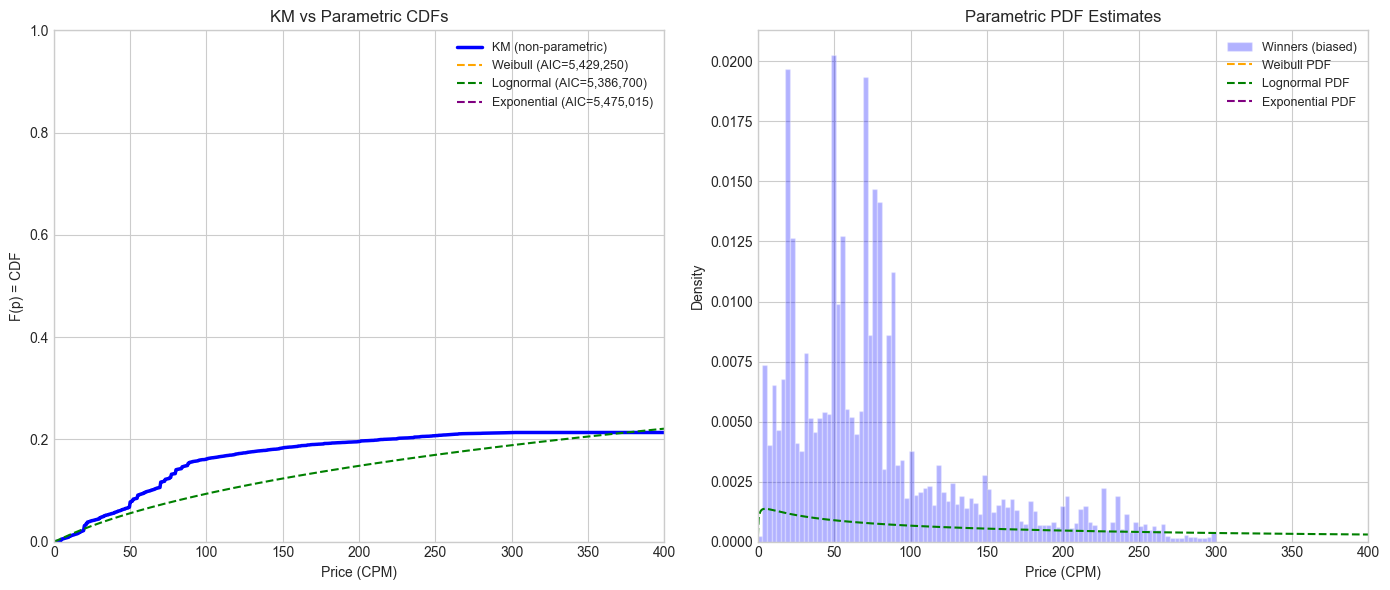

Saved: 05_parametric_vs_km.png


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_param = {'weibull': 'orange', 'lognormal': 'green', 'exponential': 'purple'}

# Left: CDF comparison
axes[0].plot(km_result.price_grid, km_result.cdf, 'b-', linewidth=2.5, label='KM (non-parametric)')
for dist_name, fit in all_fits.items():
    para_cdf = fit.cdf_fn(PRICE_GRID)
    aic_val = fit.aic
    axes[0].plot(PRICE_GRID, para_cdf, '--', linewidth=1.5,
                 color=colors_param.get(dist_name, 'gray'),
                 label=f'{dist_name.title()} (AIC={aic_val:,.0f})')

axes[0].set_xlabel('Price (CPM)')
axes[0].set_ylabel('F(p) = CDF')
axes[0].set_title('KM vs Parametric CDFs')
axes[0].set_xlim(0, 400)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)

# Right: PDF comparison
# KM empirical PDF (histogram of KM-weighted prices)
winner_prices = winners['payprice'].values
axes[1].hist(winner_prices[winner_prices < 400], bins=100, density=True,
             alpha=0.3, color='blue', label='Winners (biased)')
for dist_name, fit in all_fits.items():
    para_pdf = fit.pdf_fn(PRICE_GRID)
    axes[1].plot(PRICE_GRID, para_pdf, '--', linewidth=1.5,
                 color=colors_param.get(dist_name, 'gray'),
                 label=f'{dist_name.title()} PDF')

axes[1].set_xlabel('Price (CPM)')
axes[1].set_ylabel('Density')
axes[1].set_title('Parametric PDF Estimates')
axes[1].set_xlim(0, 400)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / '05_parametric_vs_km.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_parametric_vs_km.png')

## Section 9: S2 vs S3 Temporal Stability

We compare market price CDFs between Season 2 (June 2013) and Season 3 (October 2013)
to quantify temporal drift. EDA showed KS ≈ 0.13 with rightward CDF shift (higher prices in S3).

In [61]:
%%time
from scipy.stats import ks_2samp

# Train = S2, Test = S3 → combine for temporal comparison
df_combined = pd.concat([df_train, df_test], ignore_index=True)
print(f'Combined S2+S3: {len(df_combined):,} rows')
print(f'  S2: {(df_combined["season"]==2).sum():,}, S3: {(df_combined["season"]==3).sum():,}')

# Subsample combined for KM
N_TEMPORAL = 5_000_000
rng_t = np.random.RandomState(42)
idx_t = rng_t.choice(len(df_combined), min(N_TEMPORAL, len(df_combined)), replace=False)
df_temporal = df_combined.iloc[idx_t].copy()

# Season-level KM CDFs
season_cdfs = segment_market_cdf(
    df_temporal, segment_col='season', price_grid=PRICE_GRID, min_samples=1000
)

for s, res in sorted(season_cdfs.items()):
    med_str = f'{res.median_price:.1f}' if not np.isinf(res.median_price) else '>300'
    f300 = np.interp(300, res.price_grid, res.cdf)
    print(f'Season {s}: median={med_str} CPM, F(300)={f300:.2%}')

# KS test on observed pay prices (winners only)
winners_all = df_combined[df_combined['win'] == 1]
s2_pay = winners_all[winners_all['season'] == 2]['payprice'].values
s3_pay = winners_all[winners_all['season'] == 3]['payprice'].values

if len(s2_pay) > 0 and len(s3_pay) > 0:
    ks_stat, ks_pval = ks_2samp(s2_pay, s3_pay)
    print(f'\nKS Test (S2 vs S3 pay prices): stat={ks_stat:.4f}, p={ks_pval:.2e}')
else:
    print('\nInsufficient data for S2 vs S3 comparison')
    ks_stat = float('nan')

Combined S2+S3: 110,069,473 rows
  S2: 90,645,448, S3: 19,424,025
Season 2: median=>300 CPM, F(300)=21.34%
Season 3: median=>300 CPM, F(300)=21.96%

KS Test (S2 vs S3 pay prices): stat=0.1176, p=0.00e+00
CPU times: user 4.94 s, sys: 4.01 s, total: 8.95 s
Wall time: 10.9 s


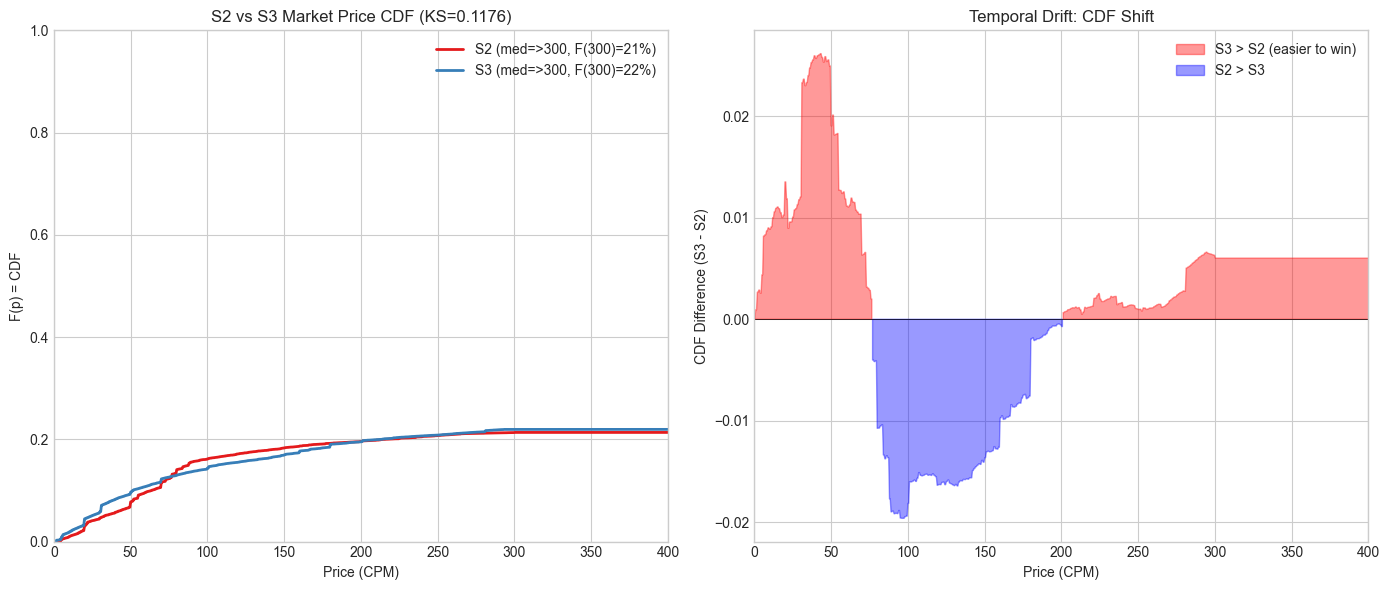

Saved: 05_temporal_drift_cdf.png


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_s = sns.color_palette('Set1', len(season_cdfs))

season_labels = {2: 'Season 2 (June)', 3: 'Season 3 (Oct)'}

# Left: CDF overlay
for i, (s, res) in enumerate(sorted(season_cdfs.items())):
    s_int = int(s) if isinstance(s, (int, float)) else s
    med_str = f'{res.median_price:.0f}' if not np.isinf(res.median_price) else '>300'
    f300 = np.interp(300, res.price_grid, res.cdf)
    label = f'{season_labels.get(s_int, f"S{s}")} (med={med_str}, F(300)={f300:.0%})'
    axes[0].plot(res.price_grid, res.cdf, linewidth=2, color=colors_s[i], label=label)

ks_str = f'{ks_stat:.4f}' if not np.isnan(ks_stat) else 'N/A'
axes[0].set_xlabel('Price (CPM)')
axes[0].set_ylabel('F(p) = CDF')
axes[0].set_title(f'S2 vs S3 Market Price CDF (KS={ks_str})')
axes[0].set_xlim(0, 400)
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: CDF difference
season_keys = sorted(season_cdfs.keys())
if len(season_keys) >= 2:
    cdf_diff = season_cdfs[season_keys[1]].cdf - season_cdfs[season_keys[0]].cdf
    axes[1].fill_between(PRICE_GRID, 0, cdf_diff, alpha=0.4,
                         color='red', where=cdf_diff > 0, label='S3 > S2 (easier to win)')
    axes[1].fill_between(PRICE_GRID, 0, cdf_diff, alpha=0.4,
                         color='blue', where=cdf_diff <= 0, label='S2 > S3')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].set_xlabel('Price (CPM)')
    axes[1].set_ylabel('CDF Difference (S3 - S2)')
    axes[1].set_title('Temporal Drift: CDF Shift')
    axes[1].set_xlim(0, 400)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Only one season available', transform=axes[1].transAxes,
                 ha='center', fontsize=14)

plt.tight_layout()
plt.savefig(FIG_PATH / '05_temporal_drift_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_temporal_drift_cdf.png')

## Section 10: Summary + SP3 Inputs

### Key Results

1. **KM Market Price CDF** provides censoring-corrected `F(p) = P(Win|bid=p)` — direct input for `shade(x) = argmax_b (v-b)*F(b)`
2. **Exchange-conditional** CDFs show significant heterogeneity → exchange-conditional shading in SP3
3. **Hourly variation** confirms U-shape → pacing multiplier `pace(t)` in SP3
4. **Parametric fit** (LogNormal or Weibull) provides closed-form CDF for optimization
5. **Temporal drift** (KS~0.13) → periodic re-estimation in production

### SP3 Connection: `bid(x) = V(x) × shade(x) × pace(t)`

- `V(x)` = debiased pCTR × CPC_target (from ESMM-WC / ESCM²-WC)
- `shade(x)` = derived from market price CDF F(p) ← **this notebook**
- `pace(t)` = budget pacing multiplier (hourly, future work)

In [63]:
# Export CDF for SP3
import json

# Save KM CDF as numpy arrays
cdf_export_path = RESULTS_PATH / 'market_price_cdf'
cdf_export_path.mkdir(parents=True, exist_ok=True)

# Overall CDF
np.savez(
    cdf_export_path / 'km_cdf_overall.npz',
    price_grid=km_result.price_grid,
    cdf=km_result.cdf,
    survival=km_result.survival,
    median_price=km_result.median_price,
)

# Exchange-conditional CDFs
for ex, res in exchange_cdfs.items():
    np.savez(
        cdf_export_path / f'km_cdf_exchange_{ex}.npz',
        price_grid=res.price_grid,
        cdf=res.cdf,
        survival=res.survival,
        median_price=res.median_price,
    )

# Summary metadata (handle inf → None for JSON)
def _safe_float(v):
    return None if np.isinf(v) or np.isnan(v) else float(v)

summary = {
    'km_median_overall': _safe_float(km_result.median_price),
    'km_f300_overall': float(np.interp(300, km_result.price_grid, km_result.cdf)),
    'exchange_medians': {ex: _safe_float(res.median_price) for ex, res in exchange_cdfs.items()},
    'exchange_f300': {ex: float(np.interp(300, res.price_grid, res.cdf)) for ex, res in exchange_cdfs.items()},
    'market_price_stats': {
        'mean': stats.mean, 'median': stats.median, 'std': stats.std,
        'p25': stats.p25, 'p75': stats.p75, 'p90': stats.p90, 'p95': stats.p95,
        'floor_binding_rate': stats.floor_binding_rate,
    },
    'best_parametric': best_dist,
    'temporal_ks': _safe_float(ks_stat),
    'overall_win_rate': float(df_train['win'].mean()),
}

with open(cdf_export_path / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Exported CDF data to {cdf_export_path}/')
print(f'Files: {sorted(p.name for p in cdf_export_path.iterdir())}')

# Verify SP3 usability: shade(x) = argmax_b (v - b) * F(b)
print('\n--- SP3 Shade Function Demo ---')
v_example = 200  # Example value per impression (CPM)
bid_range = np.linspace(1, v_example, 500)
f_b = np.interp(bid_range, km_result.price_grid, km_result.cdf)
surplus = (v_example - bid_range) * f_b
optimal_bid = bid_range[np.argmax(surplus)]
print(f'V(x) = {v_example} CPM')
print(f'Optimal bid = {optimal_bid:.1f} CPM (shade = {optimal_bid/v_example:.2%})')
print(f'Expected surplus = {surplus.max():.1f} CPM')

Exported CDF data to /Users/taehyun/project/rtb_ipinyou/results/market_price_cdf/
Files: ['km_cdf_exchange_1.npz', 'km_cdf_exchange_2.npz', 'km_cdf_exchange_3.npz', 'km_cdf_overall.npz', 'summary.json']

--- SP3 Shade Function Demo ---
V(x) = 200 CPM
Optimal bid = 89.1 CPM (shade = 44.57%)
Expected surplus = 17.2 CPM


## Section 11: Calibration의 경제적 가치 — IEB → Bid Error → Surplus Loss

IEB (Integral Error Bias)가 bid pricing에 미치는 경제적 영향을 정량화한다.

- **Linear bidding**: `bid(x) = pCTR(x) × CPC_target` → IEB가 bid error에 직결
- **Optimal bidding**: `b* = argmax_b (V(x) - b) × F(b)` → V(x) miscalibration이 surplus를 감소

KM CDF (Section 5)와 모델별 IEB (NB04 ablation 결과)를 결합하여:
1. 모델별 V(x) = pred_ctr × CPC_target 계산
2. Overall/Exchange-conditional optimal bid 도출
3. True V 기준 expected surplus 비교

True V(x) = 0.0008 × 200,000 = 160 CPM
Oracle optimal bid: b*=80.1 CPM, shade=50.1%, surplus=11.24 CPM

ESCM²-WC(DR) AL: V=162.2, b*=80.1, shade=49.4%, true_surplus=11.24 (loss=-0.0%)
ESCM²-WC(DR)+ExtPS AW: V=167.2, b*=80.1, shade=47.9%, true_surplus=11.24 (loss=-0.0%)
LR CTR_all: V=179.5, b*=89.1, shade=49.6%, true_surplus=11.00 (loss=2.2%)
LGB CTR (biased): V=217.9, b*=89.1, shade=40.9%, true_surplus=11.00 (loss=2.2%)
ESMM-WC J: V=373.6, b*=101.1, shade=27.1%, true_surplus=9.59 (loss=14.7%)

=== Exchange-Conditional Surplus ===
Ex1: oracle=25.28 | ESCM²-WC(DR)=25.28 (--0%) | ESCM²-WC(DR)+ExtPS=25.28 (-0%) | LR=24.76 (-2%) | LGB=23.22 (-8%) | ESMM-WC=14.72 (-42%)
Ex2: oracle=14.82 | ESCM²-WC(DR)=14.82 (-0%) | ESCM²-WC(DR)+ExtPS=14.82 (-0%) | LR=14.80 (-0%) | LGB=14.58 (-2%) | ESMM-WC=10.83 (-27%)
Ex3: oracle=8.09 | ESCM²-WC(DR)=8.09 (--0%) | ESCM²-WC(DR)+ExtPS=8.09 (-0%) | LR=8.09 (--0%) | LGB=8.09 (--0%) | ESMM-WC=8.08 (-0%)


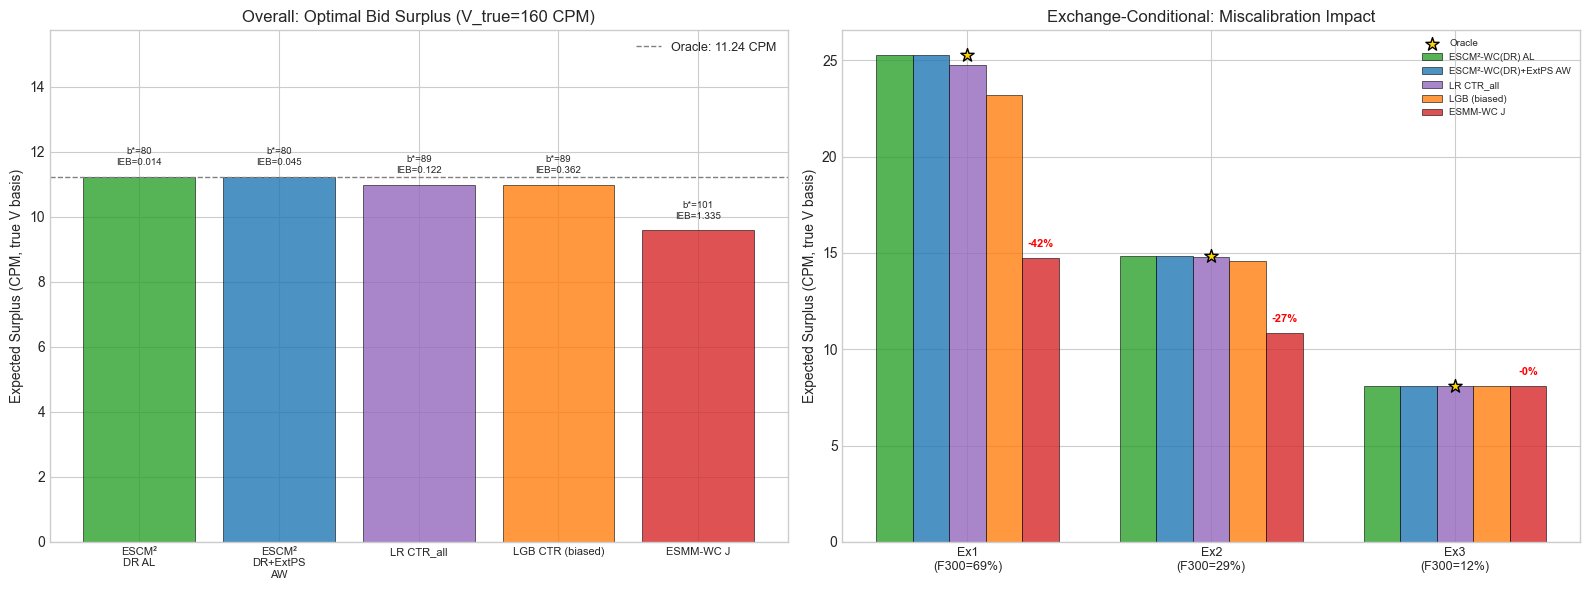

Saved: 05_calibration_economic_value.png


In [64]:
# === Calibration Economic Value Analysis ===
# Model IEB values from NB04 ablation results + NB03 baselines
ACTUAL_CTR = 0.0008  # overall CTR on all bids
CPC_TARGET = 200_000  # CPM per click (advertiser's target CPC)
V_TRUE = ACTUAL_CTR * CPC_TARGET  # 160 CPM — unbiased impression value

model_specs = [
    ('ESCM²-WC(DR) AL', 0.014, '#2ca02c'),        # best calibration
    ('ESCM²-WC(DR)+ExtPS AW', 0.045, '#1f77b4'),   # best AUC
    ('LR CTR_all', 0.122, '#9467bd'),               # all-bids LR baseline
    ('LGB CTR (biased)', 0.362, '#ff7f0e'),         # won-only LGB baseline
    ('ESMM-WC J', 1.335, '#d62728'),                # ESMM baseline
]

def find_optimal_bid(V, price_grid, cdf, n_points=5000):
    """Find b* = argmax_b (V - b) * F(b) subject to b <= V."""
    bid_range = np.linspace(1, min(V, price_grid.max()), n_points)
    f_b = np.interp(bid_range, price_grid, cdf)
    surplus = (V - bid_range) * f_b
    idx = np.argmax(surplus)
    return bid_range[idx], surplus[idx], f_b[idx]

# === Overall CDF Analysis ===
print(f'True V(x) = {ACTUAL_CTR} × {CPC_TARGET:,} = {V_TRUE:.0f} CPM')
print(f'Oracle optimal bid: ', end='')
b_oracle, s_oracle, f_oracle = find_optimal_bid(V_TRUE, km_result.price_grid, km_result.cdf)
print(f'b*={b_oracle:.1f} CPM, shade={b_oracle/V_TRUE:.1%}, surplus={s_oracle:.2f} CPM')
print()

overall_results = []
for name, ieb, color in model_specs:
    pred_ctr = ACTUAL_CTR * (1 + ieb)
    V_model = pred_ctr * CPC_TARGET
    b_star, _, f_star = find_optimal_bid(V_model, km_result.price_grid, km_result.cdf)
    # True surplus evaluated at V_TRUE, not V_model
    true_surplus = (V_TRUE - b_star) * f_star
    surplus_loss = s_oracle - true_surplus
    loss_pct = surplus_loss / s_oracle * 100 if s_oracle > 0 else 0
    overall_results.append({
        'name': name, 'ieb': ieb, 'V': V_model, 'b_star': b_star,
        'shade': b_star / V_model, 'f_star': f_star,
        'true_surplus': true_surplus, 'loss_pct': loss_pct, 'color': color,
    })
    print(f'{name}: V={V_model:.1f}, b*={b_star:.1f}, '
          f'shade={b_star/V_model:.1%}, true_surplus={true_surplus:.2f} '
          f'(loss={loss_pct:.1f}%)')

# === Exchange-Conditional Analysis ===
print('\n=== Exchange-Conditional Surplus ===')
ex_results = {}
for ex_id, ex_res in sorted(exchange_cdfs.items()):
    b_or, s_or, _ = find_optimal_bid(V_TRUE, ex_res.price_grid, ex_res.cdf)
    ex_results[ex_id] = {'oracle_surplus': s_or, 'models': {}}
    for name, ieb, color in model_specs:
        V_m = ACTUAL_CTR * (1 + ieb) * CPC_TARGET
        b_m, _, f_m = find_optimal_bid(V_m, ex_res.price_grid, ex_res.cdf)
        ts = (V_TRUE - b_m) * f_m
        loss = (s_or - ts) / s_or * 100 if s_or > 0 else 0
        ex_results[ex_id]['models'][name] = {
            'b_star': b_m, 'true_surplus': ts, 'loss_pct': loss,
        }
    print(f'Ex{ex_id}: oracle={s_or:.2f} | '
          + ' | '.join(f'{n.split(" ")[0]}={ex_results[ex_id]["models"][n]["true_surplus"]:.2f} '
                       f'(-{ex_results[ex_id]["models"][n]["loss_pct"]:.0f}%)'
                       for n, _, _ in model_specs))

# === 2-Panel Figure ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Overall optimal bid + expected surplus bar chart
ax = axes[0]
names = [r['name'].replace('ESCM²-WC(DR)', 'ESCM²\nDR').replace('+ExtPS ', '+ExtPS\n')
         for r in overall_results]
colors = [r['color'] for r in overall_results]
surpluses = [r['true_surplus'] for r in overall_results]
bids = [r['b_star'] for r in overall_results]

x_pos = np.arange(len(overall_results))
bars = ax.bar(x_pos, surpluses, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add oracle line
ax.axhline(s_oracle, color='gray', linestyle='--', linewidth=1, label=f'Oracle: {s_oracle:.2f} CPM')

# Annotate bars
for i, r in enumerate(overall_results):
    ax.text(i, r['true_surplus'] + 0.3, f'b*={r["b_star"]:.0f}\n'
            f'IEB={r["ieb"]:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel('Expected Surplus (CPM, true V basis)')
ax.set_title(f'Overall: Optimal Bid Surplus (V_true={V_TRUE:.0f} CPM)')
ax.legend(fontsize=9)
ax.set_ylim(0, max(surpluses) * 1.4)

# Right: Exchange-conditional surplus comparison
ax2 = axes[1]
ex_ids = sorted(ex_results.keys())
n_models = len(model_specs)
width = 0.15
x_ex = np.arange(len(ex_ids))

for j, (name, ieb, color) in enumerate(model_specs):
    vals = [ex_results[ex]['models'][name]['true_surplus'] for ex in ex_ids]
    short_label = name.split(' ')[0] + ' ' + name.split(' ')[-1]
    ax2.bar(x_ex + j * width, vals, width, color=color, alpha=0.8,
            edgecolor='black', linewidth=0.5, label=short_label)

# Oracle markers
oracle_vals = [ex_results[ex]['oracle_surplus'] for ex in ex_ids]
ax2.scatter(x_ex + (n_models - 1) * width / 2, oracle_vals, marker='*', s=100, color='gold',
            edgecolor='black', zorder=5, label='Oracle')

# Annotate loss % for ESMM-WC on each exchange
for i, ex in enumerate(ex_ids):
    loss = ex_results[ex]['models']['ESMM-WC J']['loss_pct']
    if loss > 0:
        y_pos = ex_results[ex]['models']['ESMM-WC J']['true_surplus']
        ax2.text(i + (n_models - 1) * width, y_pos + 0.5, f'-{loss:.0f}%',
                 ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

ax2.set_xticks(x_ex + (n_models - 1) * width / 2)
ex_labels = {1: 'Ex1\n(F300=69%)', 2: 'Ex2\n(F300=29%)', 3: 'Ex3\n(F300=12%)'}
ax2.set_xticklabels([ex_labels.get(int(ex), f'Ex{ex}') for ex in ex_ids], fontsize=9)
ax2.set_ylabel('Expected Surplus (CPM, true V basis)')
ax2.set_title('Exchange-Conditional: Miscalibration Impact')
ax2.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(FIG_PATH / '05_calibration_economic_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_calibration_economic_value.png')

In [65]:
print('=== Notebook 05 Complete ===')
print(f'Figures saved to {FIG_PATH}/')
print('  05_flat_bidding_summary.png')
print('  05_win_rate_by_bid_level.png')
print('  05_market_price_distribution.png')
print('  05_km_market_cdf.png')
print('  05_exchange_conditional_cdf.png')
print('  05_hourly_market_cdf.png')
print('  05_parametric_vs_km.png')
print('  05_temporal_drift_cdf.png')
print('  05_calibration_economic_value.png  ← NEW')

=== Notebook 05 Complete ===
Figures saved to /Users/taehyun/project/rtb_ipinyou/results/figures/
  05_flat_bidding_summary.png
  05_win_rate_by_bid_level.png
  05_market_price_distribution.png
  05_km_market_cdf.png
  05_exchange_conditional_cdf.png
  05_hourly_market_cdf.png
  05_parametric_vs_km.png
  05_temporal_drift_cdf.png
  05_calibration_economic_value.png  ← NEW
